In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#baca dataset
df = pd.read_csv("../../dataset/MLP/data.csv", sep=';')

print(df.shape)
df.head()

(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


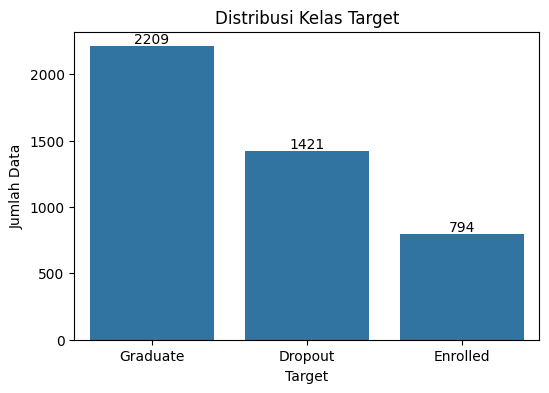

In [3]:
#cek distribusi
target_counts = df["Target"].value_counts()

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Distribusi Kelas Target")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")

# Menampilkan jumlah di atas batang
for i, value in enumerate(target_counts.values):
    ax.text(
        i,
        value + 20,
        str(value),
        ha='center'
    )

plt.show()

In [4]:
#hapus enrolled
df = df[df["Target"] != "Enrolled"].copy()

print(df["Target"].value_counts())



Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64


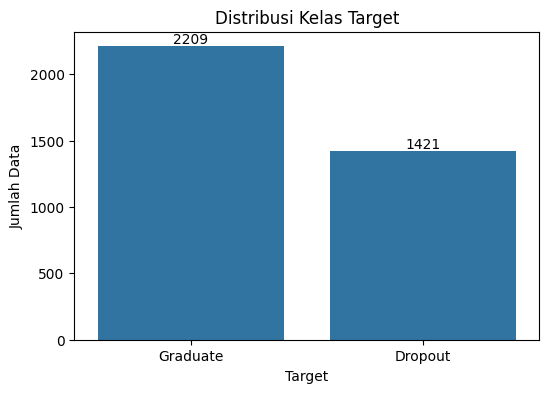

In [5]:
#cek distribusi setelah hapus enrolled
target_counts = df["Target"].value_counts()

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Distribusi Kelas Target")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")

# Menampilkan jumlah di atas batang
for i, value in enumerate(target_counts.values):
    ax.text(
        i,
        value + 20,
        str(value),
        ha='center'
    )

plt.show()

In [6]:
#encode
df["Target"] = df["Target"].map({
    "Graduate": 0,
    "Dropout": 1
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [8]:
#upsampling
graduate = df[df["Target"] == 0]
dropout = df[df["Target"] == 1]

dropout_upsampled = resample(
    dropout,
    replace=True,
    n_samples=len(graduate),
    random_state=42
)

df_balanced = pd.concat([graduate, dropout_upsampled])

print(df_balanced["Target"].value_counts())

Target
0    2209
1    2209
Name: count, dtype: int64


In [9]:
selected_features = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
]

print(f"Jumlah fitur: {len(selected_features)}")

Jumlah fitur: 2


In [10]:
#pisah fitur dan target
X = df_balanced[selected_features]
y = df_balanced["Target"]

print(X.shape)
print(y.shape)

(4418, 2)
(4418,)


In [11]:
#mixmax scaling
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(4418, 2)


In [29]:
#splot data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3534, 2)
Test : (884, 2)


In [30]:
#model MLP
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#training model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7022 - loss: 0.6417 - val_accuracy: 0.7256 - val_loss: 0.6162
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7397 - loss: 0.5635 - val_accuracy: 0.7341 - val_loss: 0.5143
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7474 - loss: 0.5040 - val_accuracy: 0.7341 - val_loss: 0.4841
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7566 - loss: 0.4896 - val_accuracy: 0.7482 - val_loss: 0.4682
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7644 - loss: 0.4852 - val_accuracy: 0.7737 - val_loss: 0.4634
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7648 - loss: 0.4842 - val_accuracy: 0.7737 - val_loss: 0.4605
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7658 - loss: 0.4819 - val_accuracy: 0.7440 - val_loss: 0.4660
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7768 - loss: 0.4789 - val_accuracy: 0.7624 - v

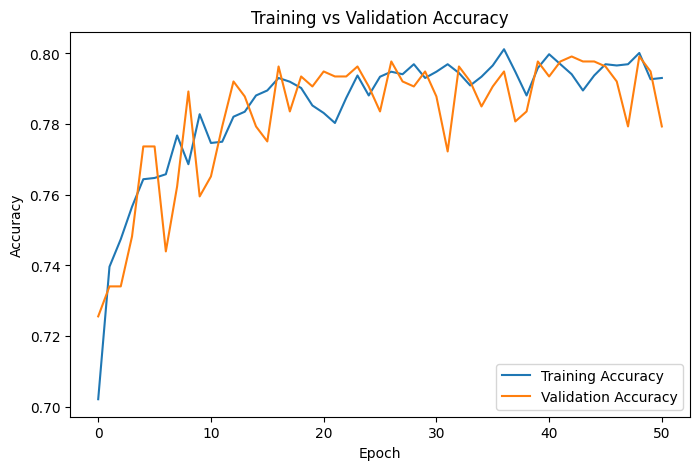

In [32]:
#grafik training
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [33]:
#prediksi
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [34]:
#evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7805
Precision: 0.7897
Recall   : 0.7647
F1 Score : 0.7770


              precision    recall  f1-score   support

     Dropout       0.77      0.80      0.78       442
    Graduate       0.79      0.76      0.78       442

    accuracy                           0.78       884
   macro avg       0.78      0.78      0.78       884
weighted avg       0.78      0.78      0.78       884



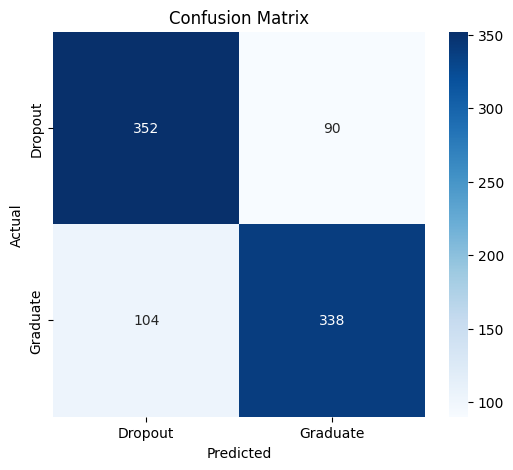

In [35]:
#classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Dropout", "Graduate"]
    )
)

#confussion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Dropout', 'Graduate'],
    yticklabels=['Dropout', 'Graduate']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [36]:
# ROC AUC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC Score : {roc_auc:.4f}")

AUC Score : 0.8479


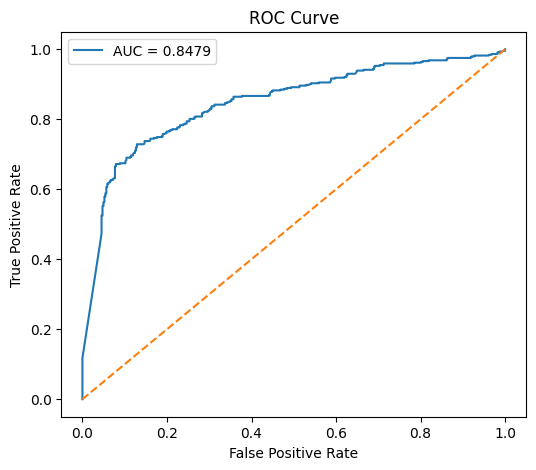

In [37]:
#plot ROC curve
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [29]:
#save model
model.save("mlp_kelulusan_mahasiswa.keras")